# diaPASEF — temporal-profile correlation between cell lines

How similar is the EGF response of each mutant cell line to wild type, and to each other?
Every cell line of `hme1_diaPASEF` is reduced to a **sites × timepoints matrix of `log2:FC` vs
starve**, and the matrices are compared.

**Site set.** Only sites with **at least one replicate at every timepoint in every cell line**
(`subset_by_coverage`, all 8 cell lines jointly, on `raw:abs`) are used. All pairs are therefore
compared on exactly the same sites. `starve` is part of the requirement, since without it there is no FC.
`full` is left out of both the requirement and the profile (`EXCLUDE_FULL`), because it is not an
EGF response. `starve` is left out of the profile because it is identically 0 on the FC scale.

**Three summaries, three questions** (functions in `src/QC.py`, section 6):

| summary | function | question | sensitive to |
|---|---|---|---|
| global r | `global_profile_correlation` | do the whole data sets agree? (all sites × timepoints flattened) | amplitude — dominated by sites that move most |
| per-site r | `per_site_profile_correlation` | does a site have the same *shape* in both cell lines? | not amplitude; noisy with 7 points → read distributions only |
| per-timepoint r | `per_timepoint_correlation` | at which time do the cell lines agree / diverge? | not a per-timepoint shift |

**Per-site r is *uncentered* by default** (cosine similarity). `log2:FC` has a natural zero, the
starve baseline, and the uncentered coefficient keeps it: up in WT and down in the mutant scores
negative. Pearson would subtract each profile's own mean and compare only the ups and downs among the
stimulated timepoints.

**How to read the numbers — calibration first.**
- `BRAFS151A1` and `BRAFS151A2` are two biological replicates of the same genotype. Their similarity is
  the practical ceiling: a mutant that is as close to WT as the two BRAF lines are to each other is
  indistinguishable from WT at this resolution.
- The **shuffled-site null** (`shuffle=True`) pairs each site with a *different* site. Whatever r
  survives it is structure shared by all sites (a global per-timepoint offset, or the generic
  early-peak shape of EGF signalling), not site identity.
- **`CENTER = "median"` (default)** subtracts, per cell line, each timepoint's median `log2:FC` across the
  selected sites. The unnormalised diaPASEF FCs carry a large shift shared by every site (median WT
  `log2:FC` −0.2 to −0.8, and a different pattern in every cell line). Left in, that shift dominates the
  uncentered per-site r, so the shuffled-site null ends up far from 0. Section 6 reruns with the other
  setting.
- Most sites do not respond to EGF, so their "profile" is noise and pulls every correlation towards the
  null. The **responsive subset** (limma omnibus F on WT) shows the comparison on sites that actually
  have a profile.

**Data track.** Profiles are taken from the batch-corrected table (the "subtract for the eyes" track;
correlations are descriptive, like PCA). The limma FFDR used to select responsive sites is taken from
the **uncorrected** limma table, because the limma columns stored in the batch-corrected file come from
a fit on corrected values. Set `USE_BATCH_CORRECTED = False` to run everything on the uncorrected table.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebooks import project code as `src.xxx`, so the repo root must be on the path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..",),)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT,)

from src.QC import (subset_by_coverage,
                    profile_matrix,
                    global_profile_correlation,
                    per_site_profile_correlation,
                    summarise_per_site_correlation,
                    per_timepoint_correlation,
                    plot_correlation_heatmap,
                    plot_correlation_to_reference,
                    plot_per_site_distributions,
                    plot_per_timepoint_correlation,
                    plot_profile_scatter_grid,)
from src.filters import filter_by_ffdr

## Parameters

In [2]:
DATA_DIR = "../../Experiment/hme1_diaPASEF/Data/Processed/"
UNCORRECTED_FILE = DATA_DIR + "20260818_peptide_MS2quant_None_transformed_limma_phPlus.tsv"
BATCH_CORRECTED_FILE = DATA_DIR + "20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv"
USE_BATCH_CORRECTED = True      # profiles from the batch-corrected table; FFDR always from the uncorrected one

CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A",]  # MIX excluded
REFERENCE = "WT"
CONDITION = "EGF"
DATA_TYPE = "log2:FC"            # FC vs starve
MIN_REPS = 1                     # >= 1 replicate at every timepoint in every cell line
EXCLUDE_FULL = True              # 'full' neither required nor used in the profile

CENTER = "median"                # None | "median": remove each timepoint's median across the selected sites (see section 6)
PER_SITE_METHOD = "uncentered"   # "uncentered" | "pearson" | "spearman"
GLOBAL_METHOD = "pearson"        # "pearson" | "spearman"
MAX_FFDR = 0.05                  # responsive subset: WT omnibus F FDR; None skips that section
RESPONSIVE_IN = ["WT"]           # cell lines whose omnibus F defines "responsive" (combine="any")

CALIBRATION = {"BRAF-S151A duplicate": ("BRAFS151A1", "BRAFS151A2",)}

SAVE_DIR = f"Results/{pd.Timestamp.today():%Y%m%d}_QC_diaPASEF_profile_correlation_files/"  # None = do not save
def out(name):
    return None if SAVE_DIR is None else os.path.join(SAVE_DIR, name,)

## Load

Only the columns needed are read (the tables are ~900 MB). `peptide_index` is unique and identical in
row order in both tables (checked 2026-09-16), so it is the join key between them. The `site` column is
taken from the uncorrected table, because the batch-corrected table rebuilt it with the phospho residues
in upper case.

In [3]:
def wanted(col):
    parts = col.split("_")
    return (col in ("peptide_index", "protein_Id", "protein_name",)
            or (len(parts) >= 4 and parts[0] in CELL_LINES and parts[2] == CONDITION
                and parts[1] in ("raw:abs", DATA_TYPE,)))

profile_file = BATCH_CORRECTED_FILE if USE_BATCH_CORRECTED else UNCORRECTED_FILE
df = pd.read_csv(profile_file, sep="\t", usecols=wanted, low_memory=False,)

ffdr_cols = [f"{cl}_log2:FFDR_{CONDITION}_omnibus" for cl in CELL_LINES]
stats = pd.read_csv(UNCORRECTED_FILE, sep="\t", usecols=["peptide_index", "site",] + ffdr_cols, low_memory=False,)
assert stats["peptide_index"].is_unique and df["peptide_index"].is_unique
df = df.merge(stats, on="peptide_index", how="left", validate="one_to_one",)

print(f"profiles from: {os.path.basename(profile_file)}")
print(f"{len(df)} sites, {df.shape[1]} columns")

profiles from: 20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv
71087 sites, 300 columns


## Site selection — at least one replicate per timepoint in every cell line

In [4]:
df_cov = subset_by_coverage(df,
                            cell_lines=CELL_LINES,
                            min_reps=MIN_REPS,
                            conditions=[f"_{CONDITION}_"],
                            data_type="raw:abs",
                            exclude_full=EXCLUDE_FULL,
                            group_label="all 8 cell lines",)

profiles = {cl: profile_matrix(df_cov.set_index("peptide_index"),
                               cell_line=cl,
                               condition=CONDITION,
                               data_type=DATA_TYPE,
                               exclude_full=EXCLUDE_FULL,
                               exclude_starve=True,
                               center=CENTER,)
            for cl in CELL_LINES}

n_incomplete = sum(int(m.isna().any(axis=1).sum()) for m in profiles.values())
print(f"timepoints in the profile: {list(profiles[REFERENCE].columns)}")
print(f"profile cells still NaN after the coverage filter: {n_incomplete} (expected 0)")

all 8 cell lines: 11807 of 71087 sites covered in >= 1 replicate(s) at every timepoint (16.6%)
timepoints in the profile: ['2', '5', '10', '15', '20', '30', '90']
profile cells still NaN after the coverage filter: 0 (expected 0)


## 1. Global correlation — all sites × timepoints

Clustered on the distance 1 − r (average linkage): cell lines that sit together in the dendrogram have
the most similar overall response.

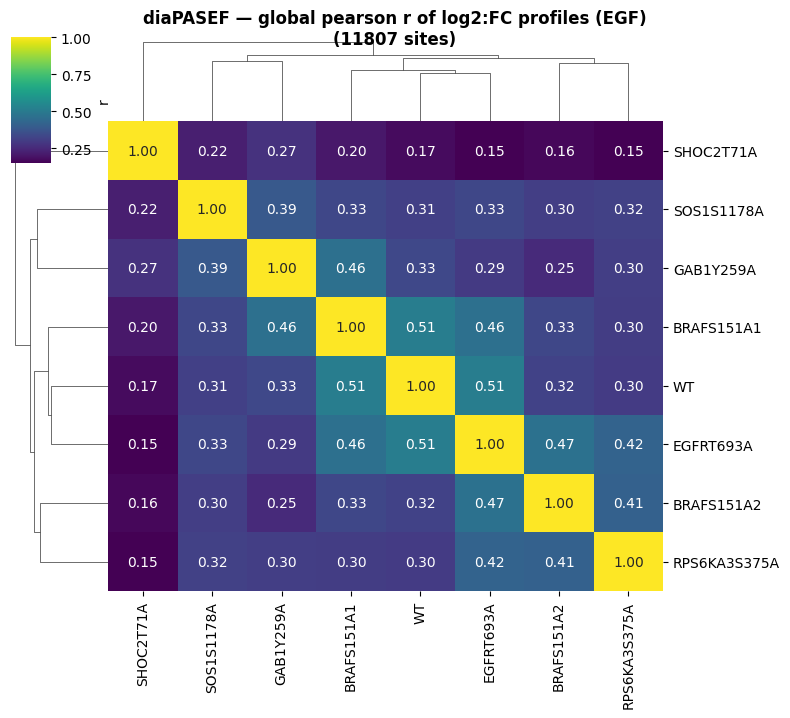

,WT,EGFRT693A,BRAFS151A1,SOS1S1178A,SHOC2T71A,BRAFS151A2,GAB1Y259A,RPS6KA3S375A
WT,1.000,0.507,0.505,0.310,0.174,0.319,0.334,0.297
EGFRT693A,0.507,1.000,0.459,0.332,0.150,0.468,0.294,0.416
BRAFS151A1,0.505,0.459,1.000,0.331,0.203,0.332,0.462,0.300
SOS1S1178A,0.310,0.332,0.331,1.000,0.221,0.304,0.385,0.315
SHOC2T71A,0.174,0.150,0.203,0.221,1.000,0.165,0.271,0.150
BRAFS151A2,0.319,0.468,0.332,0.304,0.165,1.000,0.252,0.409
GAB1Y259A,0.334,0.294,0.462,0.385,0.271,0.252,1.000,0.304
RPS6KA3S375A,0.297,0.416,0.300,0.315,0.150,0.409,0.304,1.000


In [5]:
global_r = global_profile_correlation(profiles,
                                      method=GLOBAL_METHOD,)
plot_correlation_heatmap(global_r,
                         title=f"diaPASEF — global {GLOBAL_METHOD} r of {DATA_TYPE} profiles ({CONDITION})",
                         cluster=True,
                         save_path=out("01_global_correlation_heatmap.png"),)
global_r.round(3)

## 2. Per-site profile correlation

The first figure has two panels:
- **left:** global r against WT (section 1), sorted from most to least similar. The dashed line is the
  global r between the two BRAF-S151A lines, i.e. what "same genotype" looks like;
- **right:** the distribution of **per-site** r against WT for each cell line, explained below.

### What a per-site correlation is

Take **one site** and look at its profile in two cell lines: 7 `log2:FC` values each (one per
timepoint). Those two short vectors give **one correlation coefficient r** for that site. It asks:
*does this site go up and down at the same times in both cell lines?* Doing this for every site gives
thousands of r values, one per site, and the violin plot shows their distribution.

A made-up example with 7 timepoints (2 → 90 min):

| profile | 2 | 5 | 10 | 15 | 20 | 30 | 90 | r vs site A in WT |
|---|---|---|---|---|---|---|---|---|
| site A, WT | 0.2 | 1.5 | 1.2 | 0.8 | 0.5 | 0.3 | 0.1 | — |
| site A, mutant (same shape) | 0.1 | 1.2 | 1.4 | 0.9 | 0.4 | 0.2 | 0.0 | **+0.98** |
| site A, mutant (mirror image: goes down instead of up) | −0.2 | −1.3 | −1.1 | −0.7 | −0.4 | −0.3 | 0.0 | **≈ −1** |
| a site with an unrelated profile | −0.3 | −0.1 | 0.4 | −0.6 | 0.2 | 0.5 | −0.2 | **+0.01** |

- **r near +1:** same shape. **r near −1:** opposite direction. **r near 0:** unrelated.
- The coefficient is *uncentered* (cosine similarity), so the direction relative to the starve
  baseline (0) counts. The size of the response does not: a site that rises to +3 in one cell line and
  to +0.5 in the other, with the same shape, still gets r ≈ +1. Amplitude is what the global r
  (section 1) captures.
- **One site's r means very little on its own.** With only 7 points, 1 in 20 pairs of
  unrelated random profiles already reaches r ≈ 0.6, so never read a single site. Read the *distribution*, and
  compare it with a chance level.

### What the shuffled-site chance level is

The question is: *how high would the per-site r be if the two cell lines had nothing in common site by
site?* To answer it, the function keeps the WT profiles as they are and **shuffles the rows
of the other cell line**. Site A in WT is then compared with, say, site B in the other cell line;
site B with site K; and so on. This is `per_site_profile_correlation(..., shuffle=True)`.

These pairs are wrong on purpose. Nothing links site A's profile to site B's profile, so any
agreement they show comes from one of two sources:
1. **chance**, since 7 points are few;
2. **structure that every site shares.** Examples: a shift of the whole sample at one timepoint
   (for instance a loading difference, which is why `CENTER = "median"` exists), or the generic
   "up early, back down later" shape common to many EGF-responsive sites.

The distribution of r over the shuffled pairs is the **chance level**: what you get *for free*,
without any site-specific similarity. The real per-site r only means something where it is **above
that level**.

### How to read the plot and the table

- **Violin + box:** distribution of the real per-site r for each pair. The black line is the median,
  and the box spans the middle 50% of sites.
- **Red bar:** median r of the shuffled pairs, i.e. the chance level.
- **The gap between the black median and the red bar** is the site-specific similarity. A bigger gap
  means that, site by site, the two cell lines agree more than random pairs of sites do.

| table column | meaning |
|---|---|
| `median_r` | median of the real per-site r |
| `null_median_r` | median r of the shuffled pairs (red bar) |
| `null_p95` | 95th percentile of the shuffled r: only 5% of random pairs score higher |
| `frac_above_null_p95` | fraction of real sites whose r beats that value. **With no site-specific similarity it would be about 0.05.** 0.15 means roughly 10% of sites more than chance have a profile recognisably shared between the two. It is a population-level excess, not a list of significant sites: it does not tell you *which* sites, and no FDR is controlled per site |

| what you see | what it means |
|---|---|
| real median ≈ red bar, `frac_above_null_p95` ≈ 0.05 | no detectable site-by-site similarity |
| real median well above the red bar | sites keep their own profile shape in both cell lines |
| red bar itself far from 0 | a shared structure lifts (or lowers) every r. Compare the **gap**, not the absolute median. Mostly a sign that centring is needed |
| one pair has a smaller gap than another | that pair is less similar site by site; judge the size of the difference against the calibration pair (the BRAF-S151A duplicate, `BRAFS151A1` vs `BRAFS151A2`) |

### Big gap vs small gap — what the distance between the black median and the red bar means

The gap measures how much more a site resembles **itself** in the mutant than it resembles a
**random other site**.

**Big gap.** The typical site keeps its own profile shape in both cell lines: a site that peaks at
5 min in WT tends to peak at 5 min in the mutant too. Site by site, that mutant's EGF dynamics look
like WT's. *Example (2026-09-16 run):* WT vs EGFRT693A, median 0.42, red bar 0.01, gap ≈ 0.41.

**Small gap.** A site's profile in the mutant looks no more like its own WT profile than a random
site's does. There are two possible reasons, and **this plot cannot tell them apart**:
1. **the dynamics really differ:** the mutation changed when and how the sites respond;
2. **the profiles are too noisy to compare:** most sites do not respond to EGF, so their "profile"
   is noise, and noise does not match between cell lines even when the biology is identical.

*Example:* WT vs SHOC2T71A, median 0.20, red bar ≈ 0.01, gap ≈ 0.19.

**Median below the red bar** (not seen in this data): sites tend to move in *opposite* directions in
the two cell lines.

**How big a difference between two gaps is meaningful?** Use the two BRAF-S151A lines as the
yardstick. They carry the same mutation, so their gaps to WT should match, but BRAFS151A1 gives 0.40
and BRAFS151A2 gives 0.27. Two lines that should behave the same differ by about **0.13**, so a
mutant whose gap is less than about 0.13 below another's is not clearly different from it. In the
2026-09-16 run the gaps span 0.19–0.41. Only the extremes (EGFRT693A and BRAFS151A1 against
SHOC2T71A, SOS1S1178A and RPS6KA3S375A) differ by more than that, and only just.

**Exception: the responsive-sites plot (section 5).** There the red bars already sit at about
0.86–0.92, and r cannot exceed 1, so every gap is squeezed (0.07–0.11). A small gap there does
**not** mean the mutant differs from WT: there is simply little room left above the red bar. Use that
plot to compare cell lines with each other, not to read a small gap as a difference from WT.

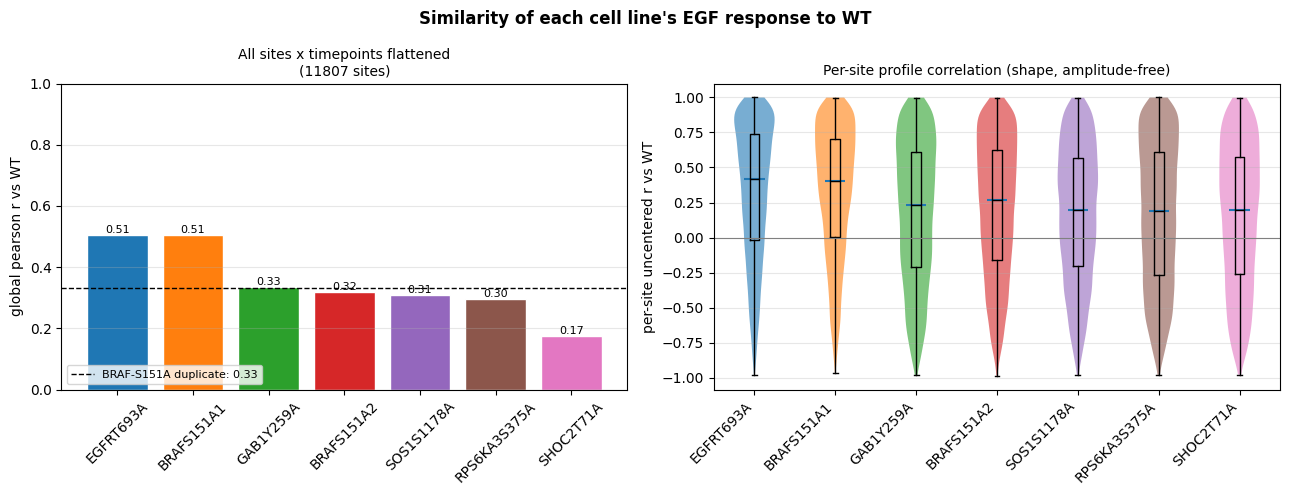

,profile,global_r,median_site_r,iqr_low,iqr_high,n_sites
0,EGFRT693A,0.507,0.415,-0.020,0.742,11807
1,BRAFS151A1,0.505,0.403,0.004,0.705,11807
2,GAB1Y259A,0.334,0.229,-0.211,0.612,11807
3,BRAFS151A2,0.319,0.267,-0.160,0.626,11807
4,SOS1S1178A,0.310,0.197,-0.205,0.565,11807
5,RPS6KA3S375A,0.297,0.189,-0.265,0.610,11807
6,SHOC2T71A,0.174,0.195,-0.263,0.573,11807


In [6]:
per_site_ref = per_site_profile_correlation(profiles,
                                            reference=REFERENCE,
                                            method=PER_SITE_METHOD,)
fig, ref_summary = plot_correlation_to_reference(global_r,
                                                 reference=REFERENCE,
                                                 per_site=per_site_ref,
                                                 calibration={k: v for k, v in CALIBRATION.items()},
                                                 title=f"Similarity of each cell line's EGF response to {REFERENCE}",
                                                 save_path=out("02_similarity_to_WT.png"),)
ref_summary.round(3)

### Chance level — shuffled sites

Same per-site r against WT as in the right panel above, now drawn next to its chance level (red bar;
see *What the shuffled-site chance level is* above). The table below the plot has the numbers.

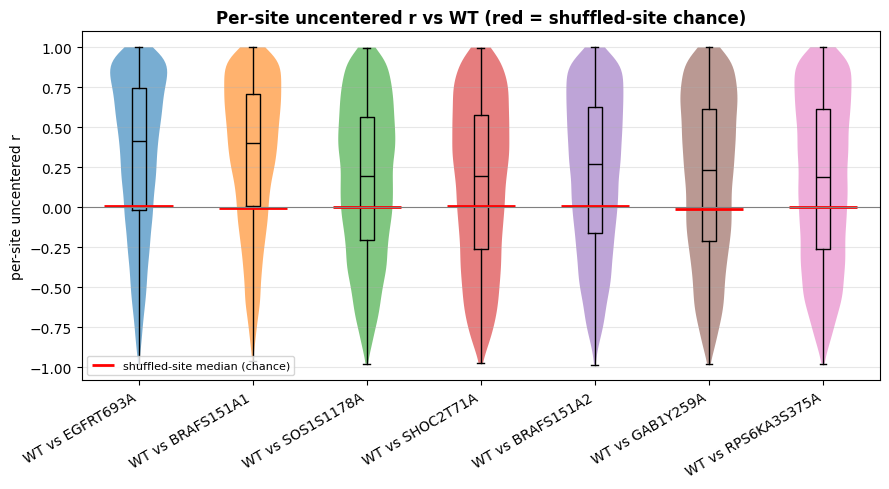

,pair,n_sites,median_r,iqr_low,iqr_high,null_median_r,null_p95,frac_above_null_p95
0,WT vs EGFRT693A,11807,0.415,-0.020,0.742,0.007,0.819,0.177
1,WT vs BRAFS151A1,11807,0.403,0.004,0.705,-0.003,0.798,0.169
2,WT vs SOS1S1178A,11807,0.197,-0.205,0.565,-0.002,0.764,0.119
3,WT vs SHOC2T71A,11807,0.195,-0.263,0.573,0.006,0.803,0.098
4,WT vs BRAFS151A2,11807,0.267,-0.160,0.626,0.006,0.790,0.129
5,WT vs GAB1Y259A,11807,0.229,-0.211,0.612,-0.010,0.805,0.115
6,WT vs RPS6KA3S375A,11807,0.189,-0.265,0.610,-0.003,0.797,0.128


In [7]:
null_ref = per_site_profile_correlation(profiles,
                                        reference=REFERENCE,
                                        method=PER_SITE_METHOD,
                                        shuffle=True,
                                        seed=0,)
fig, dist_summary = plot_per_site_distributions(per_site_ref,
                                                null=null_ref,
                                                title=f"Per-site {PER_SITE_METHOD} r vs {REFERENCE} (red = shuffled-site chance)",
                                                save_path=out("03_per_site_vs_WT_with_null.png"),)
dist_summary.round(3)

#### Reading this result (run of 2026-09-16, `CENTER = "median"`, 11,807 sites)

- **Chance level ≈ 0 for every cell line** (red bars at −0.01 to +0.01). After centring, random pairs
  of sites agree no more than coin flips, so the medians can be read directly.
- **Median per-site r vs WT:** EGFRT693A 0.42 and BRAFS151A1 0.40 are highest; SOS1S1178A,
  SHOC2T71A and RPS6KA3S375A are about 0.19–0.20.
- **`frac_above_null_p95`:** 10–18% of sites against the 5% expected by chance, so for about 5–13% of
  sites more than chance the profile shape is recognisably shared with WT. The large majority of sites
  are no more similar to WT than a random site is. Most sites do not respond to EGF, so their "profile"
  is noise. Section 5 restricts to responsive sites.
- **Calibration:** BRAFS151A2, a second line of the same genotype as BRAFS151A1, has median 0.27
  against BRAFS151A1's 0.40. Two lines that should behave the same differ by 0.13, over half the
  whole spread across cell lines (0.19–0.42). The ordering is therefore not evidence that any mutant
  differs from WT.

These numbers change if the data or parameters change. Re-read the table after re-running.

### Every pair — median per-site r

Same statistic between all cell-line pairs, including mutant vs mutant.

How to read the heatmap: each cell is the **median per-site r** between two cell lines (the black
line of a violin above, for every pair). Higher (yellow) = the two lines share site-level profile
shapes more often. The dendrogram groups lines by that similarity. The chance level is ≈ 0 for
every pair when `CENTER = "median"`, so the colours can be compared directly. With `CENTER = None`
they cannot (see section 6).

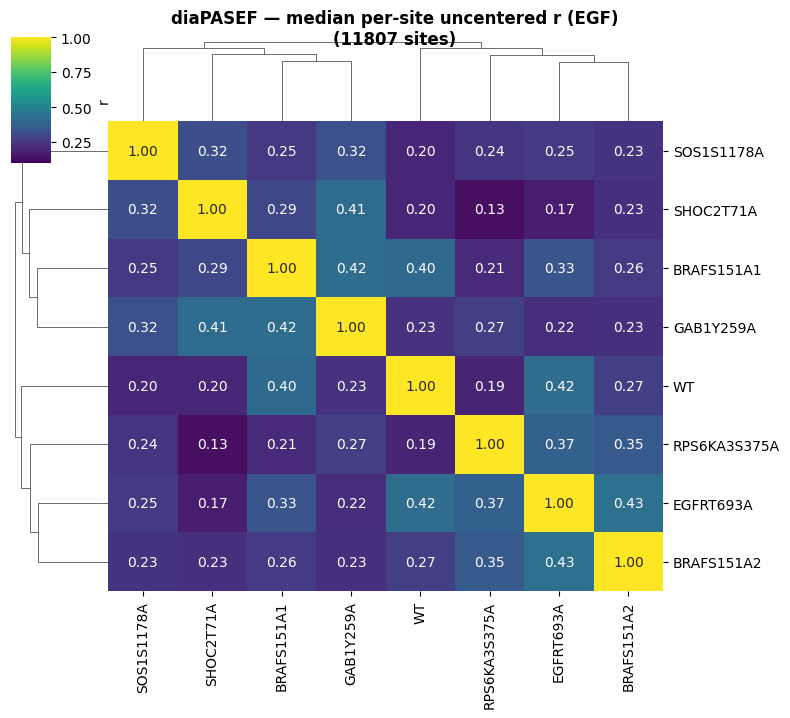

,WT,EGFRT693A,BRAFS151A1,SOS1S1178A,SHOC2T71A,BRAFS151A2,GAB1Y259A,RPS6KA3S375A
WT,1.000,0.415,0.403,0.197,0.195,0.267,0.229,0.189
EGFRT693A,0.415,1.000,0.332,0.251,0.169,0.432,0.219,0.372
BRAFS151A1,0.403,0.332,1.000,0.245,0.291,0.258,0.418,0.209
SOS1S1178A,0.197,0.251,0.245,1.000,0.317,0.233,0.323,0.239
SHOC2T71A,0.195,0.169,0.291,0.317,1.000,0.225,0.410,0.132
BRAFS151A2,0.267,0.432,0.258,0.233,0.225,1.000,0.226,0.352
GAB1Y259A,0.229,0.219,0.418,0.323,0.410,0.226,1.000,0.268
RPS6KA3S375A,0.189,0.372,0.209,0.239,0.132,0.352,0.268,1.000


In [8]:
per_site_all = per_site_profile_correlation(profiles,
                                            reference=None,
                                            method=PER_SITE_METHOD,)
median_site_r = summarise_per_site_correlation(per_site_all,
                                               stat="median",)
median_site_r.attrs["n_sites"] = len(profiles[REFERENCE])
plot_correlation_heatmap(median_site_r,
                         title=f"diaPASEF — median per-site {PER_SITE_METHOD} r ({CONDITION})",
                         cluster=True,
                         save_path=out("04_median_per_site_heatmap.png"),)
median_site_r.round(3)

## 3. Per-timepoint correlation against WT

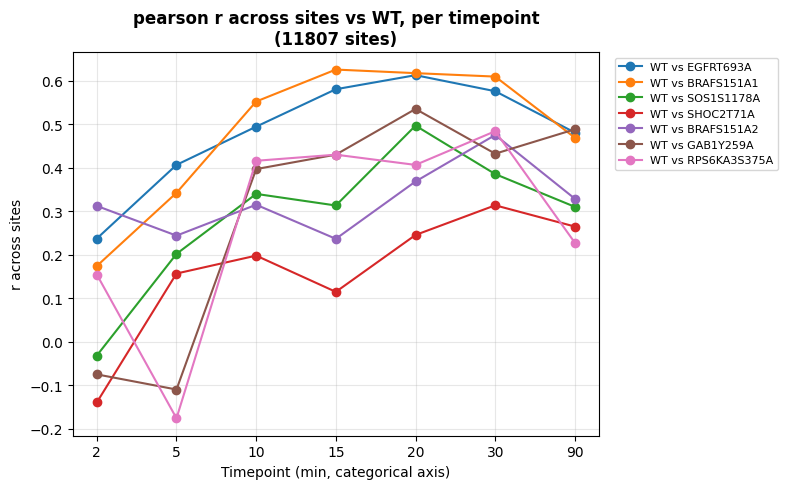

timepoint,2,5,10,15,20,30,90
profile_b,,,,,,,
BRAFS151A1,0.174,0.342,0.552,0.626,0.617,0.609,0.469
BRAFS151A2,0.312,0.244,0.315,0.237,0.368,0.475,0.329
EGFRT693A,0.237,0.407,0.494,0.580,0.613,0.576,0.481
GAB1Y259A,-0.075,-0.110,0.397,0.430,0.535,0.432,0.488
RPS6KA3S375A,0.155,-0.176,0.416,0.430,0.406,0.484,0.228
SHOC2T71A,-0.139,0.157,0.198,0.115,0.245,0.314,0.265
SOS1S1178A,-0.032,0.202,0.340,0.313,0.497,0.385,0.310


In [9]:
per_tp = per_timepoint_correlation(profiles,
                                   reference=REFERENCE,
                                   method=GLOBAL_METHOD,)
plot_per_timepoint_correlation(per_tp,
                               title=f"{GLOBAL_METHOD} r across sites vs {REFERENCE}, per timepoint",
                               save_path=out("05_per_timepoint_vs_WT.png"),)
per_tp.pivot(index="profile_b", columns="timepoint", values="r")[list(profiles[REFERENCE].columns)].round(3)

## 4. Scatter — WT against each mutant (all timepoints pooled)

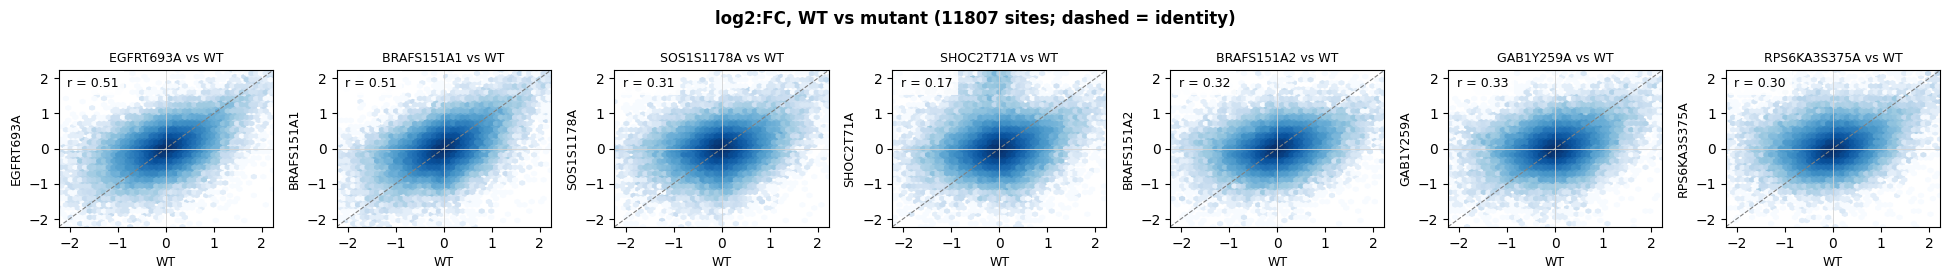

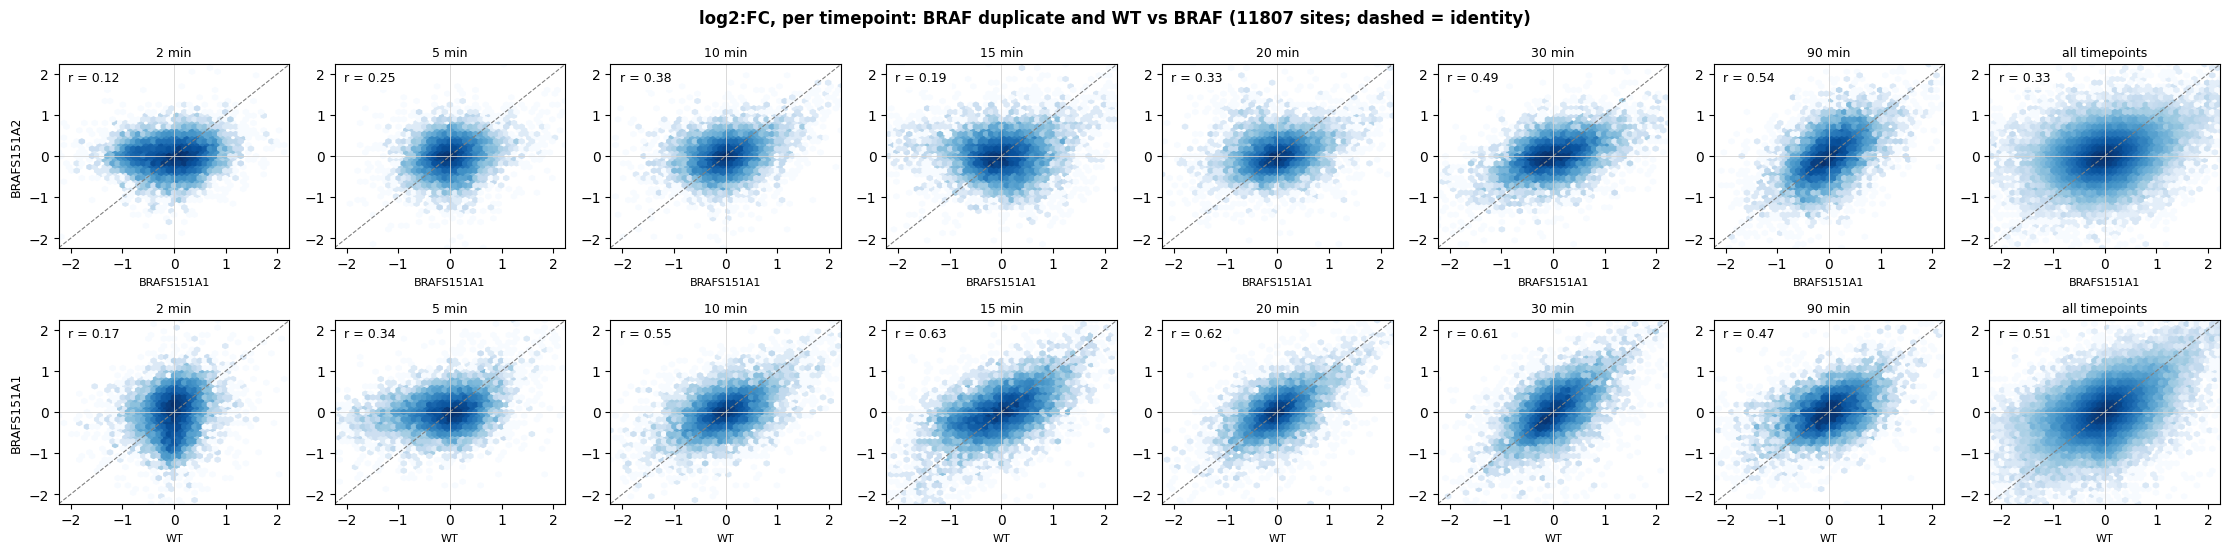

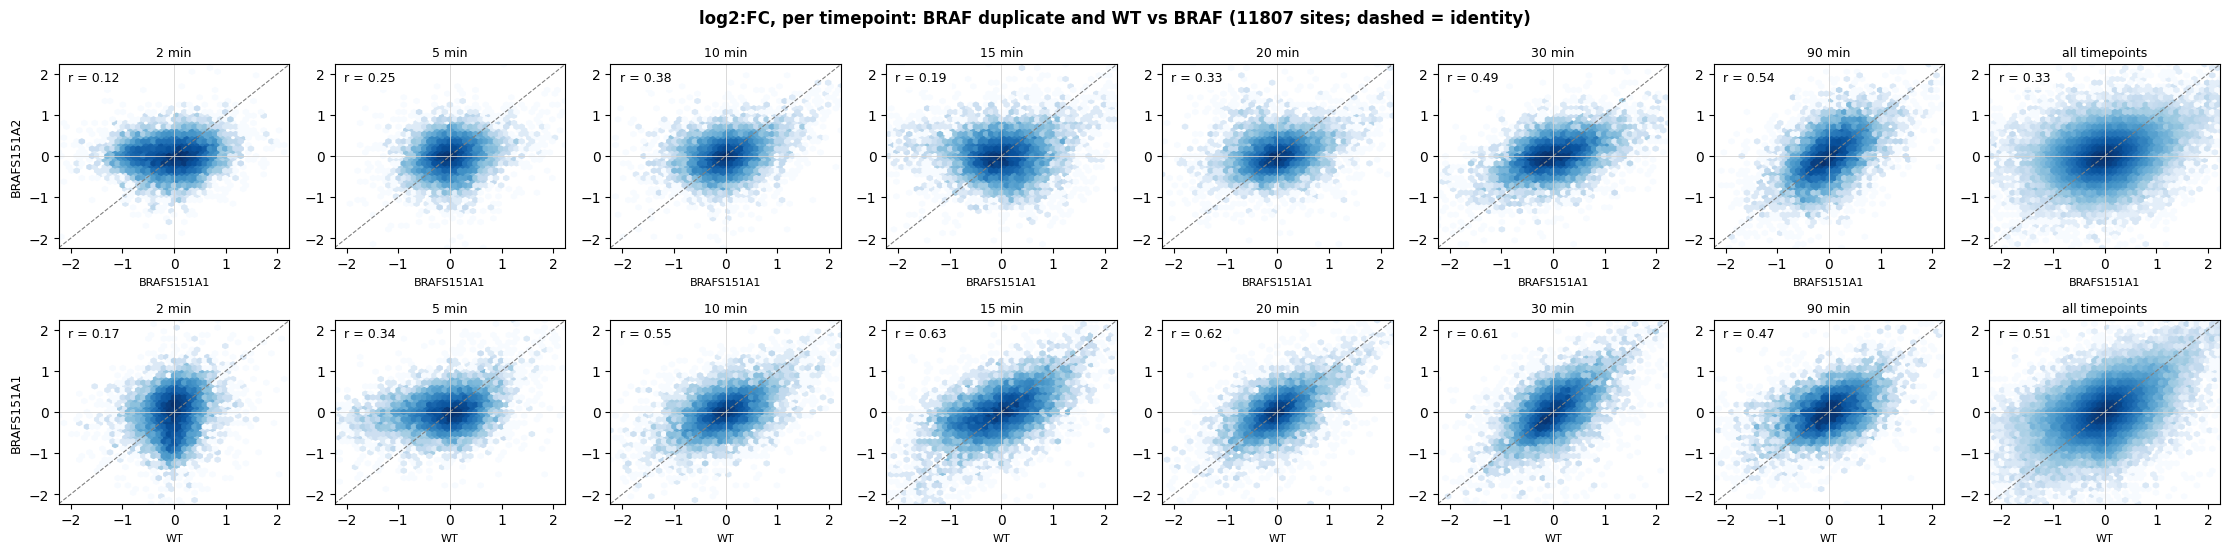

In [10]:
others = [cl for cl in CELL_LINES if cl != REFERENCE]
plot_profile_scatter_grid(profiles,
                          pairs=[(REFERENCE, cl) for cl in others],
                          by_timepoint=False,
                          title=f"{DATA_TYPE}, {REFERENCE} vs mutant",
                          save_path=out("06_scatter_WT_vs_mutants.png"),)

plot_profile_scatter_grid(profiles,
                          pairs=[CALIBRATION["BRAF-S151A duplicate"], (REFERENCE, "BRAFS151A1")],
                          by_timepoint=True,
                          title=f"{DATA_TYPE}, per timepoint: BRAF duplicate and WT vs BRAF",
                          save_path=out("07_scatter_BRAF_duplicate_by_timepoint.png"),)

## 5. Responsive sites only

Sites limma calls responsive to EGF (omnibus F, FDR < `MAX_FFDR`) in the `RESPONSIVE_IN` cell lines.
Selecting on WT alone does not use the mutant values, so it cannot inflate the WT–mutant similarity by
construction. It does bias the mutant–mutant comparison towards sites that matter in WT. The FFDR
comes from the uncorrected limma fit, and NaN (not tested) sites are dropped.

FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 88 of 11807 sites kept (11719 dropped, of which 311 never tested by limma)


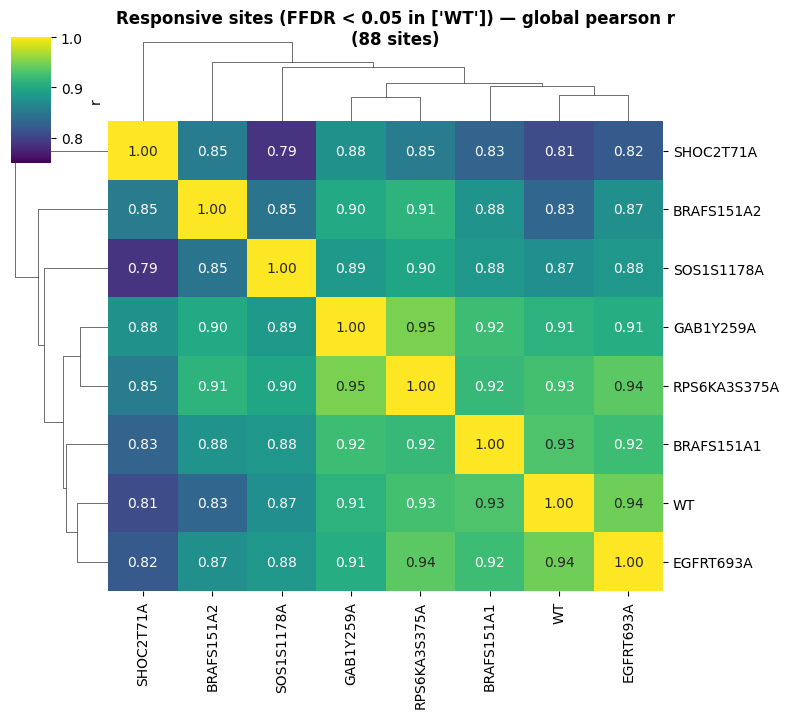

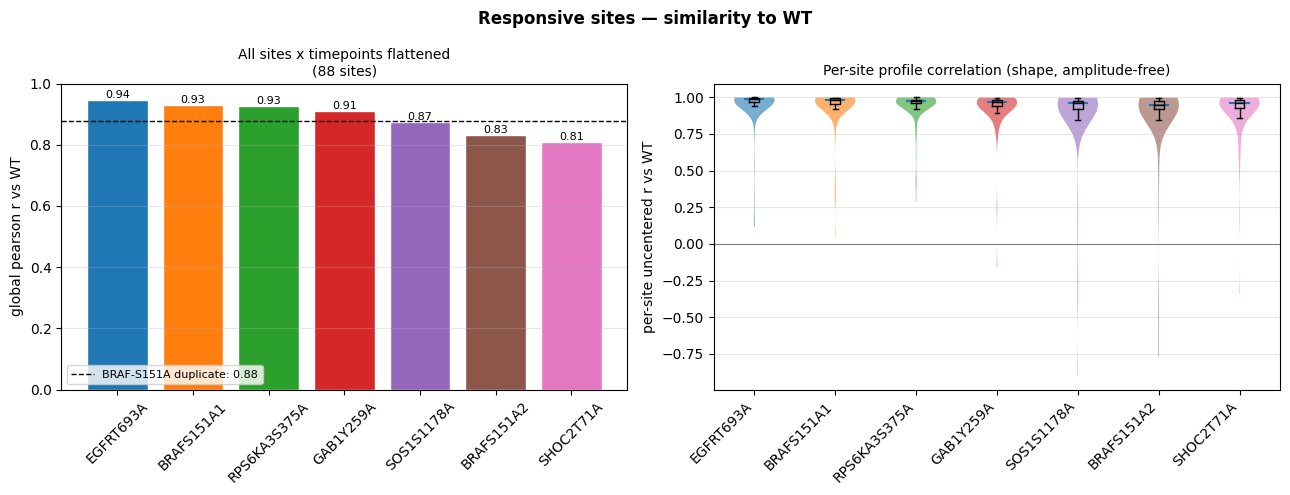

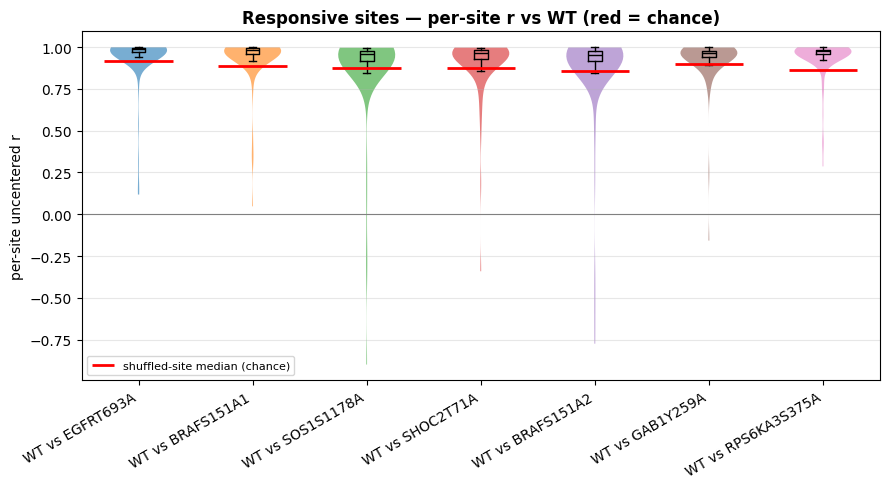

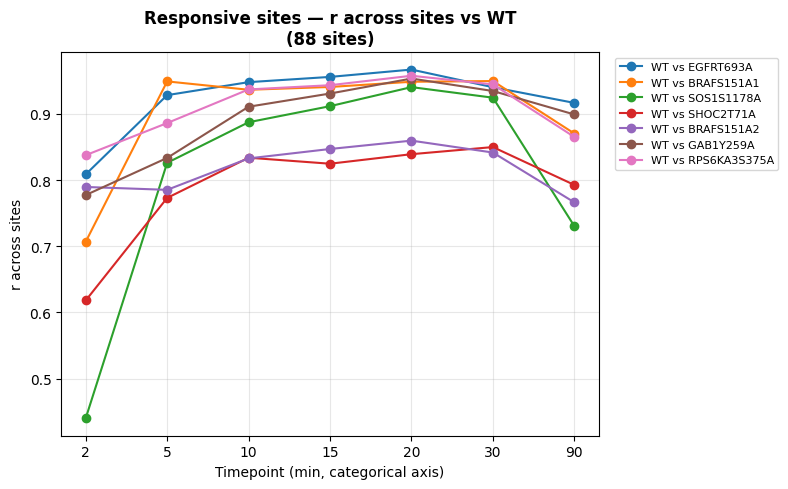

,pair,n_sites,median_r,iqr_low,iqr_high,null_median_r,null_p95,frac_above_null_p95
0,WT vs EGFRT693A,88,0.986,0.969,0.992,0.917,0.980,0.625
1,WT vs BRAFS151A1,88,0.982,0.956,0.992,0.885,0.985,0.443
2,WT vs SOS1S1178A,88,0.960,0.919,0.976,0.875,0.985,0.080
3,WT vs SHOC2T71A,88,0.963,0.928,0.979,0.874,0.980,0.239
4,WT vs BRAFS151A2,88,0.950,0.918,0.975,0.858,0.974,0.295
5,WT vs GAB1Y259A,88,0.966,0.941,0.979,0.901,0.988,0.125
6,WT vs RPS6KA3S375A,88,0.975,0.959,0.983,0.861,0.992,0.102


In [11]:
if MAX_FFDR is not None:
    df_resp = filter_by_ffdr(df_cov,
                             cell_lines=RESPONSIVE_IN,
                             conditions=[f"_{CONDITION}_"],
                             max_ffdr=MAX_FFDR,
                             combine="any",
                             verbose=True,)
    profiles_resp = {cl: m.loc[m.index.isin(df_resp["peptide_index"])] for cl, m in profiles.items()}

    global_resp = global_profile_correlation(profiles_resp,
                                             method=GLOBAL_METHOD,)
    plot_correlation_heatmap(global_resp,
                             title=f"Responsive sites (FFDR < {MAX_FFDR} in {RESPONSIVE_IN}) — global {GLOBAL_METHOD} r",
                             save_path=out("08_responsive_global_heatmap.png"),)

    per_site_resp = per_site_profile_correlation(profiles_resp,
                                                 reference=REFERENCE,
                                                 method=PER_SITE_METHOD,)
    null_resp = per_site_profile_correlation(profiles_resp,
                                             reference=REFERENCE,
                                             method=PER_SITE_METHOD,
                                             shuffle=True,)
    fig, resp_summary = plot_correlation_to_reference(global_resp,
                                                      reference=REFERENCE,
                                                      per_site=per_site_resp,
                                                      calibration=CALIBRATION,
                                                      title=f"Responsive sites — similarity to {REFERENCE}",
                                                      save_path=out("09_responsive_similarity_to_WT.png"),)
    fig, resp_dist = plot_per_site_distributions(per_site_resp,
                                                 null=null_resp,
                                                 title="Responsive sites — per-site r vs WT (red = chance)",
                                                 save_path=out("10_responsive_per_site_with_null.png"),)
    plot_per_timepoint_correlation(per_timepoint_correlation(profiles_resp,
                                                             reference=REFERENCE,
                                                             method=GLOBAL_METHOD,),
                                   title=f"Responsive sites — r across sites vs {REFERENCE}",
                                   save_path=out("11_responsive_per_timepoint.png"),)
    display(resp_dist.round(3))

#### Reading the responsive-site plots — why the red bars are so high here

On responsive sites the chance level jumps to **≈ 0.86–0.92** (run of 2026-09-16, 88 sites), and
the real medians are 0.95–0.99. That does **not** mean the cell lines are almost identical. Most
EGF-responsive sites share the same generic shape (up within minutes, then back down), so even two
*different* responsive sites correlate strongly. Only the **gap** says something site-specific: here
it is small (0.07–0.11). This is a ceiling effect, not a difference from WT: r cannot exceed 1, so
little room is left above the red bar (see *Big gap vs small gap*, section 2).
`frac_above_null_p95` ranges from 0.08 (SOS1S1178A) to 0.63 (EGFRT693A). With 88 sites, each of those fractions is uncertain by roughly ±0.05–0.10.

## 6. Sensitivity — the other centring setting

Everything above used `CENTER`. This section repeats sections 1–2 with the opposite setting.
Centring removes, in every cell line separately, the part of the response every site shares. That
part could be a loading offset or a genuine global change, and the phospho table alone cannot tell
the two apart. A conclusion that holds only without centring rests on that shared shift rather than on
site-specific behaviour. Per-timepoint r (section 3) is unaffected by construction.

**What this does to the chance level.** Without centring, each cell line keeps its own shift
(the median table printed below). A shift shared by every site makes even random pairs of sites look
alike, or unlike, so the red bars move away from 0. In the 2026-09-16 run: BRAFS151A1 null 0.52 with a
real median of 0.69; SOS1S1178A null −0.12 with a real median of 0.01. The uncentred medians therefore
**cannot be ranked against each other**. Only the gap to each pair's own red bar is comparable, and
EGFRT693A has the largest gap in both runs (0.21 uncentred, 0.41 centred), but the order of the
other lines is not the same in the two runs, another sign that the ordering is fragile.

median log2:FC per timepoint before centring (the shift that centring removes):


,2,5,10,15,20,30,90
WT,-0.200,-0.518,-0.575,-0.619,-0.254,-0.439,-0.756
EGFRT693A,-0.020,0.038,0.083,-0.365,-0.363,0.061,-0.431
BRAFS151A1,-0.312,-0.212,-0.226,-0.286,-0.384,-0.392,-0.405
SOS1S1178A,0.111,0.360,0.058,0.118,0.075,0.149,-0.186
SHOC2T71A,-0.011,-0.073,0.144,0.286,0.033,-0.140,-0.567
BRAFS151A2,-0.271,0.140,-0.110,0.021,-0.141,-0.239,-0.489
GAB1Y259A,-0.149,-0.016,0.064,0.199,-0.041,-0.013,-0.437
RPS6KA3S375A,-0.172,-0.038,-0.114,0.024,-0.099,0.030,-0.239


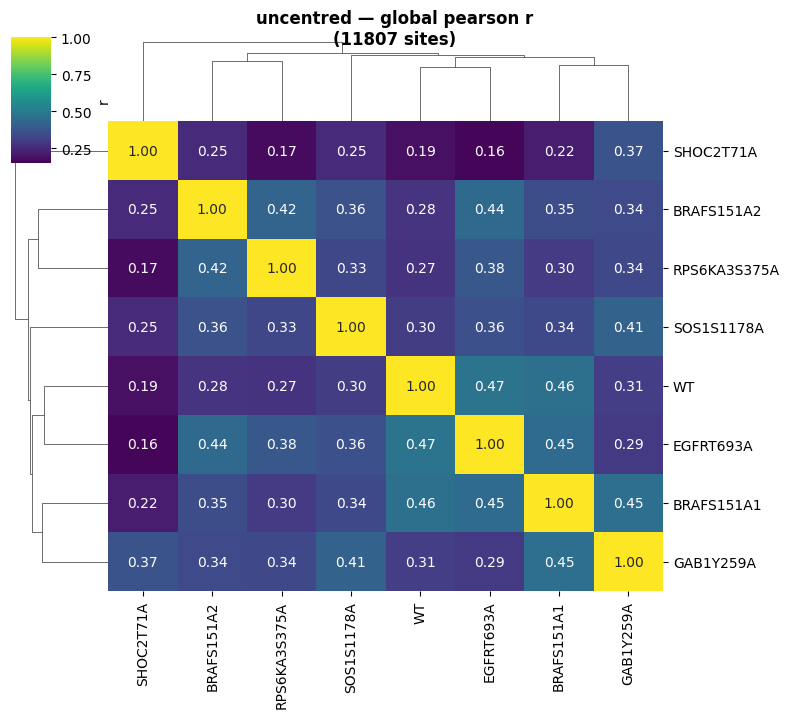

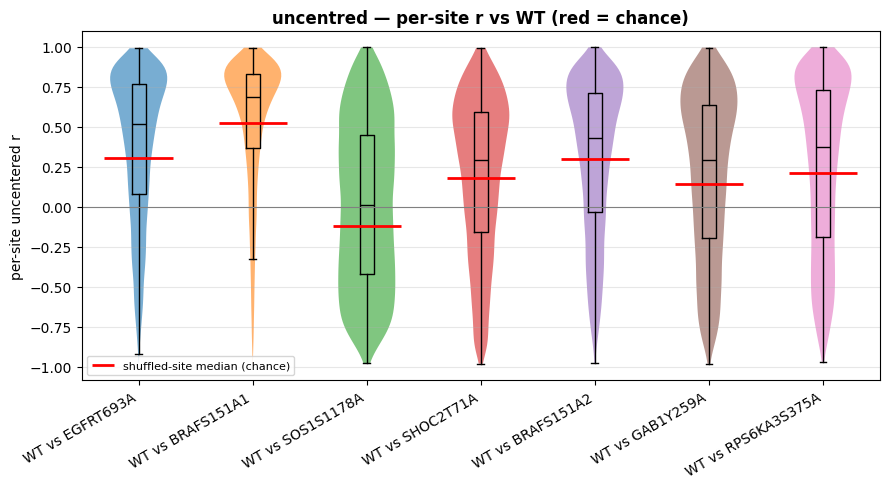

,global_r (CENTER=median),global_r (uncentred),median_site_r (CENTER=median),null (CENTER=median),median_site_r (uncentred),null (uncentred)
EGFRT693A,0.507,0.474,0.415,0.007,0.515,0.307
BRAFS151A1,0.505,0.460,0.403,-0.003,0.686,0.523
GAB1Y259A,0.334,0.306,0.229,-0.010,0.295,0.145
BRAFS151A2,0.319,0.278,0.267,0.006,0.433,0.301
SOS1S1178A,0.310,0.303,0.197,-0.002,0.013,-0.122
RPS6KA3S375A,0.297,0.273,0.189,-0.003,0.373,0.212
SHOC2T71A,0.174,0.186,0.195,0.006,0.291,0.179


In [12]:
ALT_CENTER = None if CENTER == "median" else "median"
ALT_LABEL = "uncentred" if ALT_CENTER is None else "median-centred"
profiles_c = {cl: profile_matrix(df_cov.set_index("peptide_index"),
                                 cell_line=cl,
                                 condition=CONDITION,
                                 data_type=DATA_TYPE,
                                 exclude_full=EXCLUDE_FULL,
                                 center=ALT_CENTER,)
              for cl in CELL_LINES}
print("median log2:FC per timepoint before centring (the shift that centring removes):")
display(pd.DataFrame({cl: profile_matrix(df_cov.set_index("peptide_index"),
                                         cell_line=cl,
                                         condition=CONDITION,
                                         data_type=DATA_TYPE,
                                         exclude_full=EXCLUDE_FULL,).median()
                      for cl in CELL_LINES}).T.round(3))

global_c = global_profile_correlation(profiles_c,
                                      method=GLOBAL_METHOD,)
plot_correlation_heatmap(global_c,
                         title=f"{ALT_LABEL} — global {GLOBAL_METHOD} r",
                         save_path=out("12_centred_global_heatmap.png"),)
per_site_c = per_site_profile_correlation(profiles_c,
                                          reference=REFERENCE,
                                          method=PER_SITE_METHOD,)
null_c = per_site_profile_correlation(profiles_c,
                                      reference=REFERENCE,
                                      method=PER_SITE_METHOD,
                                      shuffle=True,)
fig, centred_dist = plot_per_site_distributions(per_site_c,
                                                null=null_c,
                                                title=f"{ALT_LABEL} — per-site r vs WT (red = chance)",
                                                save_path=out("13_centred_per_site_with_null.png"),)

def by_line(table, col):
    return table.set_index(table["pair"].str.split(" vs ").str[1])[col]

comparison = pd.DataFrame({f"global_r (CENTER={CENTER})": global_r.loc[REFERENCE].drop(REFERENCE),
                           f"global_r ({ALT_LABEL})": global_c.loc[REFERENCE].drop(REFERENCE),
                           f"median_site_r (CENTER={CENTER})": by_line(dist_summary, "median_r"),
                           f"null (CENTER={CENTER})": by_line(dist_summary, "null_median_r"),
                           f"median_site_r ({ALT_LABEL})": by_line(centred_dist, "median_r"),
                           f"null ({ALT_LABEL})": by_line(centred_dist, "null_median_r"),})
comparison.sort_values(comparison.columns[0], ascending=False).round(3)

## Notes on interpretation

- Similarity here is **descriptive**. It orders the cell lines, but it does not test whether a mutant
  differs from WT. That question belongs to a joint limma model with mutant × time contrasts, which has
  not been built yet (see CLAUDE.md, "limma on diaPASEF").
- A mutant's distance from WT only means something **relative to the BRAF duplicate**. Differences
  between clones, culture batches and acquisition order are all folded into that reference.
- The coverage filter keeps sites detected in all 8 cell lines, which biases towards abundant,
  well-quantified phosphopeptides. Sites switched off completely in a mutant are excluded by
  construction.